## Lake Zug Gliders Proposal

In [1]:
# imports
import ewgreaders as ewg
import ewgdatsci as dsi
import xarray as xr
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import cmocean
from tqdm.notebook import tqdm
import os
import json
from glob import glob

In [2]:
lake = 'Zug'

breader = ewg.bathy_reader.BathyReader(lake)
bathy = breader.load()

meteo = []
for yr in ['2024', '2025', '2026']:
    mreader = ewg.meteo_reader.MeteoReader(lake, yr, 'cham')
    ds = mreader.load()
    meteo.append(ds)

meteo = xr.concat(meteo, dim='time')

di_m = ewg.get_data_index(lake, 'mooring')
di_ctd = ewg.get_data_index(lake, 'ctd')

c:\Users\herremha\AppData\Local\anaconda3\envs\ewg\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
DLL load failed while importing _context: The specified module could not be found.
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


### Topography and Bathymetry

In [16]:
locs = pd.DataFrame([
    {'loc': 'N', 'xsc': 679227, 'ysc': 220396, 'color':'tab:red',},
    {'loc': 'W', 'xsc': 679917, 'ysc': 218754, 'color': 'tab:orange'},
    {'loc': 'C', 'xsc': 680091, 'ysc': 218814, 'color': 'tab:blue'},
    {'loc': 'E', 'xsc': 680326, 'ysc': 218879, 'color': 'tab:purple'},
    {'loc': 'S', 'xsc': 680442, 'ysc': 216813, 'color': 'tab:green'}
])

locs['xsc'] = locs['xsc'] + int(2e6)
locs['ysc'] = locs['ysc'] + int(1e6)

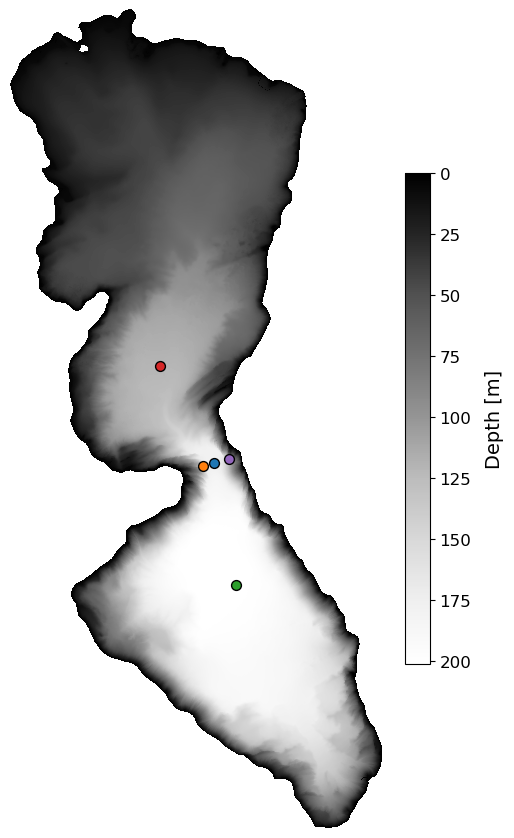

In [17]:
ratio = (bathy.ysc.max() - bathy.ysc.min()).item() / (bathy.xsc.max() - bathy.xsc.min()).item()

fig, ax = plt.subplots(figsize=(6, 6*ratio-3))

im = ax.pcolormesh(bathy['xsc'], bathy['ysc'], bathy['depth'], cmap='Greys_r', vmin=0, rasterized=True)
cbar = fig.colorbar(im, shrink=0.6, ax=ax)
cbar.set_label('Depth [m]', fontsize=14, labelpad=10)
cbar.ax.tick_params(labelsize=12)
cbar.ax.invert_yaxis()

for _, row in locs.iterrows():
    ax.scatter(x=row.xsc, y=row.ysc, c=row.color, edgecolor='black', s=50)

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/collab/gliders/zug_bathy.svg', bbox_inches='tight')
plt.show()

### Anoxic Depth in Constriction and South Basin

In [10]:
def transect_min_do(di_sel):
    min_do = []
    for _, p in di_sel.iterrows():
        ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
        try:
            ds = ctdreader.load()
            min_do.append(ds['do2_conc'].min().item())
        except FileNotFoundError:
            continue

    return min(min_do)

In [3]:
date = '2026-04-10'
loc = 'LZC'
sensor = 'minidot'

di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)

datasets = []
for _, row in di_sel.iterrows():
    oreader = ewg.o2_reader.O2Reader(row.lake, row.date, row.location, row.serial_id)
    ds = oreader.load()
    datasets.append(ds)
ds_do = mreader.create_instrument_chain(datasets)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:228: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


In [4]:
do = ds_do['do2_conc']
iso_z = dsi.lakes.isoline_t(do, 0.3)

In [12]:
t_start, t_end = do.time.values[0], do.time.values[-1]
di = di_ctd[di_ctd['date'].between(t_start, t_end)]

min_do_map = {}
for dt, di_sel in tqdm(di.groupby('date')):
    min_do = transect_min_do(di_sel)
    min_do_map[dt] = min_do


  0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
s_basin = ["P9", "P9'", "VMPS", "P10", "P10'", "PS", "LZ3"]
constriction_center = ["P6", "VMPC", "PC", "P7"]
constriction_boundary = ["P6W", "P6E", "P6E'", "VMPW", "P7W"]

anoxia_data = []
for _, p in tqdm(di.iterrows(), total=len(di)):
    if p.profile_loc in s_basin + constriction_center + constriction_boundary:
        ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
        min_do = min_do_map[p.date]
        basin = 'S' if p.profile_loc in s_basin else 'C'
        region = 'S' if p.profile_loc in s_basin else 'C' if p.profile_loc in constriction_center else 'B'

        try:
            ds = ctdreader.load()
            mask = ds['do2_conc'] <= min_do + 0.1
            if mask.sum() > 0:
                anoxic_depth = ds.where(mask, drop=True).depth.min().item()
            else:
                anoxic_depth = np.nan
            
            anoxia_data.append({
                    'date': p.date,
                    'time': p.time,
                    'basin': basin,
                    'region': region,
                    'profile_loc': p.profile_loc,
                    'xsc': p.xsc,
                    'ysc': p.ysc,
                    'sensor': p.sensor,
                    'serial_id': p.serial_id,
                    'profile_depth': ds.depth.max().item(),
                    'anoxic_depth': anoxic_depth,
                })
        except FileNotFoundError:
            continue

anoxia_data = pd.DataFrame(anoxia_data)

  0%|          | 0/21 [00:00<?, ?it/s]

In [47]:
z_min = 100
z_max = 145
ratio = (do.depth.max().item() - do.depth.min().item()) / (z_max - z_min)

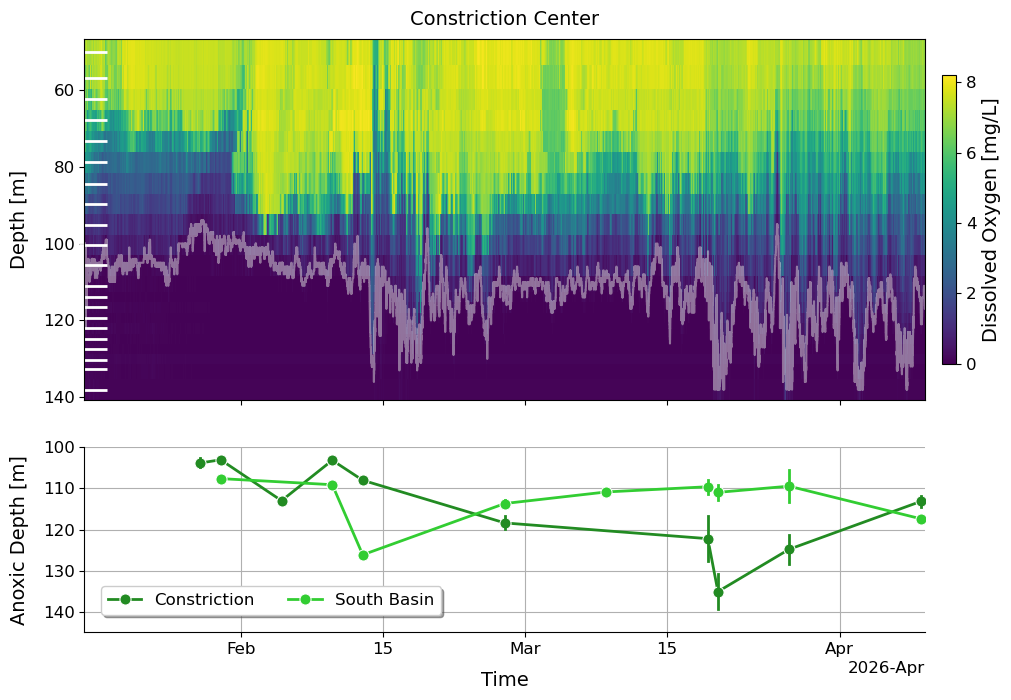

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 7), sharex=True, height_ratios=[ratio, 1], layout='constrained')
basin_order = ['C', 'S']
palette = ['forestgreen', 'limegreen']

# dO2 from constriction mooring
im = do.plot(cmap='viridis', vmin=0, cbar_kwargs={'shrink': 0.8, 'pad': 0.02, 'label': 'Dissolved Oxygen [mg/L]'}, ax=ax[0], rasterized=True)
im.colorbar.ax.yaxis.label.set_size(14)
im.colorbar.ax.tick_params(labelsize=12)

# 0.3 mg/L isoline
sns.lineplot(x=iso_z.time, y=iso_z, color='gainsboro', alpha=0.5, ax=ax[0])

# oxygen loggers
for d in ds_do.depth:
    ax[0].plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax[0].get_yaxis_transform(), clip_on=False)

# anoxic depth from CTD (constriction v. S basin)
sns.lineplot(anoxia_data, x='date', y='anoxic_depth', hue='basin', hue_order=basin_order, palette=palette, 
             marker='o', markersize=8, linewidth=2, errorbar=('se', 1), err_style='bars', err_kws={'linewidth': 2}, ax=ax[1])

ax[0].set_xlabel('')
ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[1].set_ylabel('Anoxic Depth [m]', fontsize=14, labelpad=10)
ax[0].set_title('Constriction Center', fontsize=14, pad=10)
ax[1].xaxis.get_offset_text().set_fontsize(12)

ax[1].spines[['right', 'top']].set_visible(False)
ax[1].grid(True)
ax[1].set_ylim(z_min, z_max)

labels = ['Constriction', 'South Basin']
handles, _ = ax[1].get_legend_handles_labels()
ax[1].legend(handles, labels, fontsize=12, ncols=2, shadow=True, loc='lower left', bbox_to_anchor=(0.01, 0.05))

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].invert_yaxis()

fig.get_layout_engine().set(h_pad=0.1, hspace=0.1)
plt.savefig('../gallery/collab/gliders/o2_anoxia.svg', bbox_inches='tight')
plt.show()

### Overall circulation

Wind = primary forcing mechanism.  Activates internal seiche that transports water between N and S basin.


In [3]:
t_start, t_end = '2024-03-01', '2024-04-03'

xc, yc = 680101, 218799
lat, lon = dsi.utils.ch1903_to_latlng(xc, yc)
f = dsi.efd.coriolis_frequency(lat)
f_hz = dsi.utils.angular_frequency_to_frequency(f)

In [4]:
# N-S wind, 1-hour rolling average
v_wind = dsi.signal.wind_projection(meteo['wind_speed'], meteo['wind_direction'], 90).sel(time=slice(t_start, t_end))
v_wind_ra = v_wind.rolling(time=6, center=True).mean()

In [9]:
date = '2024-04-04'
sensor = 'adcp'

# constriction
loc = 'LZC'
di_sel = di_m[(di_m['date'] == date) & (di_m['sensor'] == sensor) & (di_m['location'] == loc)]
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)

adcp_c = []
for _, row in di_sel.iterrows():
    areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
    ds = areader.load()
    ds = dsi.signal.valid_depths(ds, 0.5)
    ds['depth'] = ds['depth'].round(0)
    adcp_c.append(ds)
adcp_c = mreader.create_adcp_chain(adcp_c, gap=np.arange(133, 140)).sel(time=slice(t_start, t_end))

# south basin
loc = 'LZS'
di_sel = di_m[(di_m['date'] == date) & (di_m['sensor'] == sensor) & (di_m['location'] == loc)]
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)

adcp_s = []
for _, row in di_sel.iterrows():
    areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
    ds = areader.load()
    ds = dsi.signal.valid_depths(ds, 0.5)
    ds['depth'] = ds['depth'].round(0)
    adcp_s.append(ds)
adcp_s = mreader.create_adcp_chain(adcp_s, gap=np.arange(98, 109), drop=np.array([109])).sel(time=slice(t_start, t_end))

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:257: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:257: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.co

In [12]:
# horizontal currents
uc = adcp_c.vel.sel(dir='E')
vc = adcp_c.vel.sel(dir='N')
us = adcp_s.vel.sel(dir='E')
vs = adcp_s.vel.sel(dir='N')

In [13]:
range_c = vc.depth.max() - vc.depth.min() 
range_s = vs.depth.max() - vs.depth.min()
ratio = range_c / range_s

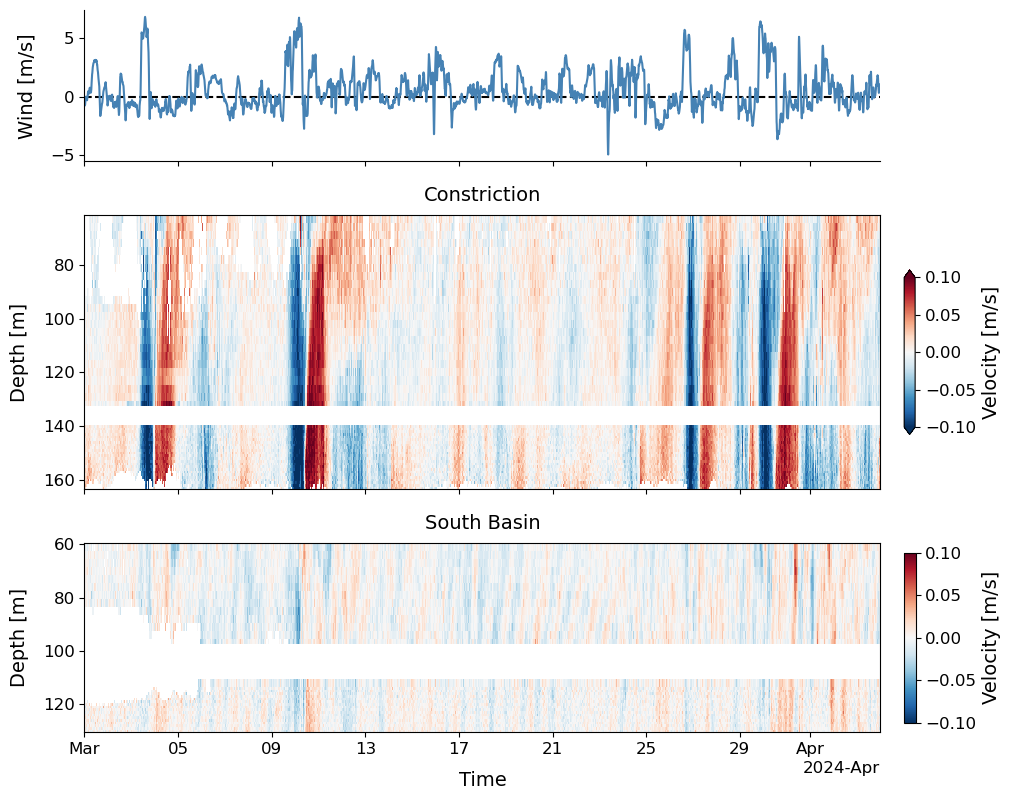

In [22]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, height_ratios=[0.8, ratio, 1], layout='constrained')

# N-S wind
ax[0].axhline(0, color='black', linestyle='--')
sns.lineplot(x=v_wind_ra.time, y=v_wind_ra, color='steelblue', ax=ax[0])

# N-S current velocity, constriction
im = vc.sel(time=slice(t_start, t_end)).plot(x='time', y='depth', cmap='RdBu_r', vmin=-0.1, vmax=0.1, cbar_kwargs={'shrink': 0.6, 'aspect': 15, 'pad': 0.03, 'label': 'Velocity [m/s]'}, ax=ax[1], rasterized=True)
im.colorbar.ax.yaxis.label.set_size(14)
im.colorbar.ax.tick_params(labelsize=12)

# N-S current velocity, S basin
im = vs.sel(time=slice(t_start, t_end)).plot(x='time', y='depth', cmap='RdBu_r', vmin=-0.1, vmax=0.1, cbar_kwargs={'shrink': 0.9, 'aspect': 15, 'pad': 0.03, 'label': 'Velocity [m/s]'}, ax=ax[2], rasterized=True)
im.colorbar.ax.yaxis.label.set_size(14)
im.colorbar.ax.tick_params(labelsize=12)

ax[1].set_xlabel('')
ax[2].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('Wind [m/s]', fontsize=14, labelpad=10)
ax[1].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[2].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[1].set_title('Constriction', fontsize=14, pad=10)
ax[2].set_title('South Basin', fontsize=14, pad=10)
ax[1].xaxis.get_offset_text().set_fontsize(12)
ax[2].xaxis.get_offset_text().set_fontsize(12)

ax[0].spines[['right', 'top']].set_visible(False)
ax[1].invert_yaxis()
ax[2].invert_yaxis()

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)

fig.get_layout_engine().set(h_pad=0.1, hspace=0.05)
plt.savefig('../gallery/collab/gliders/wind_vel_ns.svg', bbox_inches='tight')
plt.show()

### Spatial Variability of Turbulence

In [3]:
root = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/'
years = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d)) and d.isdigit()]

di_u = []
for yr in years:
    root_yr = os.path.join(root, yr, 'Microstructure')

    dates = os.listdir(root_yr)
    for dt in dates:
        root_dt = os.path.join(root_yr, dt)
        
        md_files = glob(f'{root_dt}/*_md.json')
        for md_file in md_files:
            with open(md_file, 'r') as f:
                md = json.load(f)

            if md['sensor'] == 'microCTD':
                fname = '_'.join(os.path.basename(md_file).split('_')[:2])
            elif md['sensor'] == 'VMP':
                fname = os.path.basename(md_file).split('_')[0]

            di_u.append({
                'lake': md['lake'],
                'date': pd.to_datetime(md['date']),
                'time': md['time'],
                'profile_loc': md['profile_loc'],
                'xsc': md['xsc'],
                'ysc': md['ysc'],
                'sensor': md['sensor'],
                'fname': fname,
                'profile_num': os.path.basename(md_file).split('_')[-2]
            })

di_u = pd.DataFrame(di_u)

In [11]:
dates = ['2025-11-28', '2026-01-13', '2026-02-13']
di_sel = di_u[di_u['date'].isin(dates)]

eps_data = []
for _, p in di_sel.iterrows():
    if p.profile_loc in ['VMPW', 'VMPC', 'VMPS']:
        ureader = ewg.u_reader.uReader(p.lake, p.date, p.fname, p.profile_num)
        ds = ureader.load()

        mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0)
        eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')
        eps = eps.to_dataframe().reset_index().rename(columns={'BINNED_depth': 'depth', 'BINNED_eps_T1': 'eps'})
        eps[['date', 'profile_loc']] = p.date, p.profile_loc
        eps_data.append(eps)

eps_data = pd.concat(eps_data, ignore_index=True)

C:\Users\herremha\AppData\Local\Temp\ipykernel_6808\2738991650.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_sel = di_u[di_u['date'].isin(dates)]


In [15]:
# 5-meter median
bins = np.arange(0, eps_data['depth'].max() + 5, 5)
bc = bins[:-1] + 2.5
eps_data['depth_bin'] = pd.cut(eps_data['depth'], bins=bins, labels=bc, right=False)

eps_data_med = eps_data.groupby(['date', 'profile_loc', 'depth_bin'], as_index=False)['eps'].median()

C:\Users\herremha\AppData\Local\Temp\ipykernel_6808\21548596.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eps_data_med = eps_data.groupby(['date', 'profile_loc', 'depth_bin'], as_index=False)['eps'].median()


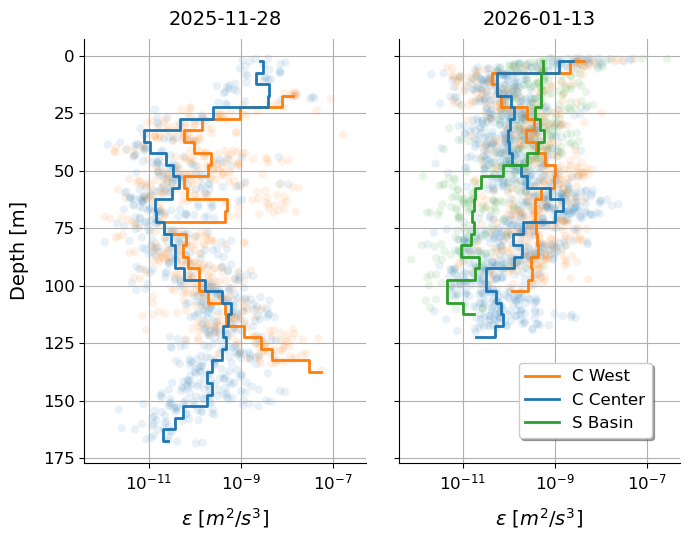

In [212]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 5.5), sharex=True, sharey=True)
pl_order = ['VMPW', 'VMPC', 'VMPS']
palette = ['tab:orange', 'tab:blue', 'tab:green']

# 2025-11-28
sns.scatterplot(eps_data[eps_data['date'] == '2025-11-28'], x='eps', y='depth', hue='profile_loc', hue_order=pl_order, palette=palette, alpha=0.1, ax=ax[0], legend=False)
sns.lineplot(eps_data_med[eps_data_med['date'] == '2025-11-28'], x='eps', y='depth_bin', orient='y', hue='profile_loc', hue_order=pl_order, palette=palette, 
             linewidth=2, drawstyle='steps-mid', ax=ax[0], legend=False)

# 2026-01-13
sns.scatterplot(eps_data[eps_data['date'] == '2026-01-13'], x='eps', y='depth', hue='profile_loc', hue_order=pl_order, palette=palette, alpha=0.1, ax=ax[1], legend=False)
sns.lineplot(eps_data_med[eps_data_med['date'] == '2026-01-13'], x='eps', y='depth_bin', orient='y', hue='profile_loc', hue_order=pl_order, palette=palette, 
             linewidth=2, drawstyle='steps-mid', ax=ax[1])

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[0].set_title('2025-11-28', fontsize=14, pad=10)
ax[1].set_title('2026-01-13', fontsize=14, pad=10)

labels = ['C West', 'C Center', 'S Basin']
handles, _ = ax[1].get_legend_handles_labels()
ax[1].get_legend().remove()
fig.legend(handles, labels, fontsize=12, ncols=1, shadow=True, loc='lower right', bbox_to_anchor=(0.95, 0.18))

for i in range(len(ax)):
    ax[i].set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)
    ax[i].set_xscale('log')

plt.tight_layout(w_pad=2)
plt.savefig('../gallery/collab/gliders/eps_spatial.svg', bbox_inches='tight')
plt.show()

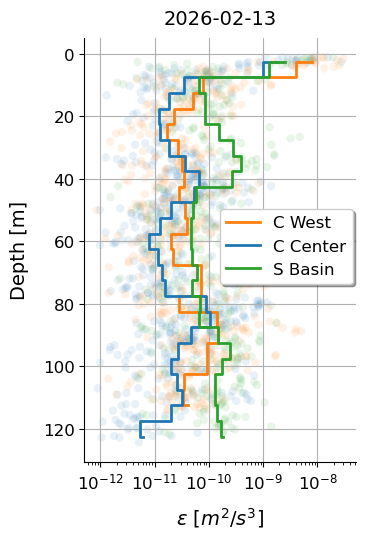

In [403]:
fig, ax = plt.subplots(figsize=(3.5, 5.5))
pl_order = ['VMPW', 'VMPC', 'VMPS']
palette = ['tab:orange', 'tab:blue', 'tab:green']

# 2026-02-13
sns.scatterplot(eps_data[eps_data['date'] == '2026-02-13'], x='eps', y='depth', hue='profile_loc', hue_order=pl_order, palette=palette, alpha=0.1, ax=ax, legend=False)
sns.lineplot(eps_data_med[eps_data_med['date'] == '2026-02-13'], x='eps', y='depth_bin', orient='y', hue='profile_loc', hue_order=pl_order, palette=palette, 
             linewidth=2, drawstyle='steps-mid', ax=ax)

ax.set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('2026-02-13', fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.set_xscale('log')

labels = ['C West', 'C Center', 'S Basin']
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=12, ncols=1, shadow=True, loc='lower right', bbox_to_anchor=(1.02, 0.4))

plt.savefig('../gallery/collab/gliders/eps_2026_02_13.svg', bbox_inches='tight')
plt.show()

In [189]:
pl_n = ["P4", "VMPN", "P4'"]
pl_w = ["P6W", "VMPW"]
pl_c = ["P6", "VMPC", "PC", "P7"]
pl_e = ["P6E"]
pl_s = ["P10", "VMPS", "LZ3", "P10'"]

In [191]:
data_ad = []
for _, p in tqdm(di_ctd.iterrows(), total=len(di_ctd)):
    if p.profile_loc in pl_n + pl_w + pl_c + pl_e + pl_s:
        ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
        ds = ctdreader.load()

        if ds['depth'].max() < 110:
            continue
        
        # select out below 80 meters (hypolimion/deep water)
        ds = ds.sel(depth=slice(80, 110))
        
        # thorpe displacement
        rho = ds['rho']
        depth = ds['depth']
        rho_ra = dsi.signal.rolling_average_z(rho, ra_window=1)
        rho_ra_sort = dsi.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
        thorpe_displacement = depth - rho_ra_sort.depth.values
        thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

        data_ad.append({
            'date': p.date,
            'profile_loc': p.profile_loc,
            'basin': 'N' if p.profile_loc in pl_n else 'W' if p.profile_loc in pl_w else 'C' if p.profile_loc in pl_c else 'E' if p.profile_loc in pl_e else 'S',
            'thorpe_scale': thorpe_scale
        })

data_ad = pd.DataFrame(data_ad)

  0%|          | 0/422 [00:00<?, ?it/s]

In [192]:
# average within date
data_ad_avg = data_ad.groupby(['date', 'basin'])['thorpe_scale'].mean().reset_index()

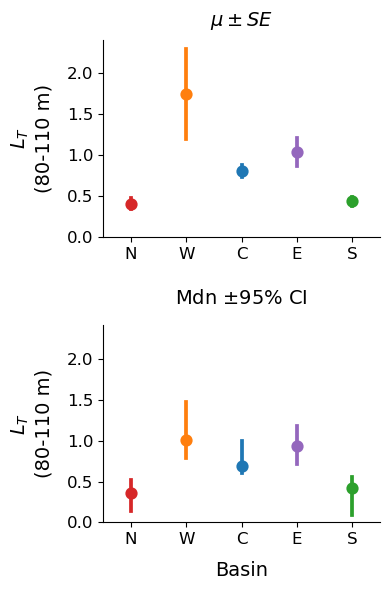

In [207]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(4, 6), sharey=True)
pl_order = ['N', 'W', 'C', 'E', 'S']
palette = ['tab:red', 'tab:orange', 'tab:blue', 'tab:purple', 'tab:green']

#ax.axhline(0, color='black', linestyle='--')
sns.pointplot(data_ad_avg, x='basin', y='thorpe_scale', estimator=np.mean, order=pl_order, hue='basin', hue_order=pl_order, palette=palette, errorbar=('se', 1), linestyle='none', ax=ax[0])
sns.pointplot(data_ad_avg, x='basin', y='thorpe_scale', estimator=np.median, order=pl_order, hue='basin', hue_order=pl_order, palette=palette, errorbar=('ci', 95), linestyle='none', ax=ax[1])

ax[0].set_xlabel('')
ax[1].set_xlabel('Basin', fontsize=14, labelpad=10)
ax[0].set_title(r'$\mu \pm SE$', fontsize=14, pad=10)
ax[1].set_title(r'Mdn $\pm$' + '95% CI', fontsize=14, pad=15)

for i in range(len(ax)):
    ax[i].set_ylabel(r'$L_{T}$' + '\n(80-110 m)', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
   
ax[0].set_ylim(0, None)

plt.tight_layout(h_pad=2)
plt.savefig('../gallery/collab/gliders/thorpe_spatial.svg', bbox_inches='tight')
plt.show()

### Turbulence as function of flow

Thorpe scale, oxygen overturns

In [445]:
date = '2026-01-14'
loc = 'LZC'
sensor = 'adcp'
di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)

datasets = []
for _, row in di_sel.iterrows():
    areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
    ds = areader.load()
    ds = dsi.signal.valid_depths(ds, 0.5)
    ds['depth'] = ds['depth'].round(0)
    datasets.append(ds)

ds_adcp = mreader.create_adcp_chain(datasets, gap=np.arange(67, 77))

# horizontal flow speed
u = ds_adcp.vel.sel(dir='E').sel(depth=slice(85, 125))
v = ds_adcp.vel.sel(dir='N').sel(depth=slice(85, 125))
speed1 = np.sqrt(u**2 + v**2).mean(dim='depth')

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:257: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [446]:
date = '2026-04-10'
loc = 'LZC'
sensor = 'adcp'
di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)

datasets = []
for _, row in di_sel.iterrows():
    areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
    ds = areader.load()
    ds = dsi.signal.valid_depths(ds, 0.5)
    ds['depth'] = ds['depth'].round(0)
    datasets.append(ds)

ds_adcp = mreader.create_adcp_chain(datasets, gap=np.arange(77, 87))

# horizontal flow speed
u = ds_adcp.vel.sel(dir='E').sel(depth=slice(85, 125))
v = ds_adcp.vel.sel(dir='N').sel(depth=slice(85, 125))
speed2 = np.sqrt(u**2 + v**2).mean(dim='depth')

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:257: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [447]:
# concatenate flow speed timeseries
speed = xr.concat([speed1, speed2], dim='time')

In [448]:
t_start = speed.time.values[0]
t_end = speed.time.values[-1]
di_sel = di_ctd[(di_ctd['date'].between(t_start, t_end)) & (di_ctd['profile_loc'].isin(['P6', 'PC', 'VMPC']))]

thorpe_data = []
for _, p in tqdm(di_sel.iterrows(), total=len(di_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()

    if ds['depth'].max() < 125:
        continue
    
    # select out below 85 meters (hypolimnion/deep water), calculate thorpe scale
    ds = ds.sel(depth=slice(85, 125))
    rho = ds['rho']
    depth = ds['depth']
    rho_ra = dsi.signal.rolling_average_z(rho, ra_window=1)
    rho_ra_sort = dsi.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
    thorpe_displacement = depth - rho_ra_sort.depth.values
    thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

    # flow 30 minutes prior to profile
    tf = ds['time'].values[0]
    t0 = tf - pd.Timedelta(minutes=30)

    thorpe_data.append({
        'date': p.date,
        'time': tf,
        'thorpe_scale': thorpe_scale,
        'speed': speed.sel(time=slice(t0, tf)).mean().item(),
    })

thorpe_data = pd.DataFrame(thorpe_data).dropna()

  0%|          | 0/40 [00:00<?, ?it/s]

In [449]:
r, p = scipy.stats.pearsonr(thorpe_data.speed, thorpe_data.thorpe_scale, alternative='two-sided')

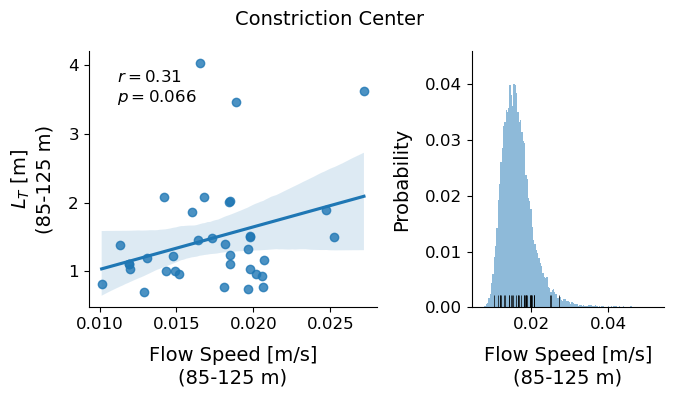

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 4), width_ratios=[1.5, 1])

sns.regplot(thorpe_data, x='speed', y='thorpe_scale', color='tab:blue', ax=ax[0])

txtstr = f'$r = {r:.2f}$\n$p = {p:.3e}$' if p < 0.001 else f'$r = {r:.2f}$\n$p = {p:.3f}$'
ax[0].annotate(txtstr, xy=(0.1, 0.8), xycoords='axes fraction', fontsize=12)

# horizontal flow speed distribution
sns.histplot(x=speed, stat='probability', color='tab:blue', edgecolor='none', alpha=0.5, ax=ax[1])

# speed during CTD profiles
sns.rugplot(thorpe_data, x='speed', height=0.05, color='black', linewidth=0.5, ax=ax[1])

ax[0].set_ylabel(r'$L_{T}$ [m]' + '\n(85-125 m)', fontsize=14, labelpad=10)
ax[1].set_ylabel('Probability', fontsize=14, labelpad=10)
fig.suptitle('Constriction Center', fontsize=14)

for i in range(len(ax)):
    ax[i].set_xlabel('Flow Speed [m/s]\n(85-125 m)', fontsize=14, labelpad=10)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].tick_params(axis='both', labelsize=12)

plt.tight_layout(h_pad=1)
plt.savefig('../gallery/collab/gliders/flow_thorpe_c.svg', bbox_inches='tight')
plt.show()

In [456]:
date = '2026-04-10'
loc = 'LZW'
sensor = 'adcp'
row = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)].iloc[0]

areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds = areader.load()
ds = dsi.signal.valid_depths(ds, 0.5)

# horizontal flow speed
u = ds_adcp.vel.sel(dir='E').sel(depth=slice(107, 117))
v = ds_adcp.vel.sel(dir='N').sel(depth=slice(107, 117))
speed = np.sqrt(u**2 + v**2).mean(dim='depth')

In [457]:
t_start = speed.time.values[0]
t_end = speed.time.values[-1]
di_sel = di_ctd[(di_ctd['date'].between(t_start, t_end)) & (di_ctd['profile_loc'].isin(['VMPW', 'P6W']))]

thorpe_data = []
for _, p in tqdm(di_sel.iterrows(), total=len(di_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()

    print(ds['depth'].max().item())
    if ds['depth'].max() < 117:
        continue
    
    # select out below 85 meters (hypolimnion/deep water), calculate thorpe scale
    ds = ds.sel(depth=slice(107, 117))
    rho = ds['rho']
    depth = ds['depth']
    rho_ra = dsi.signal.rolling_average_z(rho, ra_window=1)
    rho_ra_sort = dsi.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
    thorpe_displacement = depth - rho_ra_sort.depth.values
    thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

    # flow 30 minutes prior to profile
    tf = ds['time'].values[0]
    t0 = tf - pd.Timedelta(minutes=30)

    thorpe_data.append({
        'date': p.date,
        'time': tf,
        'thorpe_scale': thorpe_scale,
        'speed': speed.sel(time=slice(t0, tf)).mean().item(),
    })

thorpe_data = pd.DataFrame(thorpe_data).dropna()

  0%|          | 0/12 [00:00<?, ?it/s]

119.9748180758356
110.25068615625457
117.42415067079772
120.73069816577205
134.37416478352702
118.34933344460157
128.60883215588476
131.795383604607
126.85156762104235
125.04086441243963
126.81547685941922
130.32944504338653


In [458]:
r, p = scipy.stats.pearsonr(thorpe_data.speed, thorpe_data.thorpe_scale, alternative='two-sided')

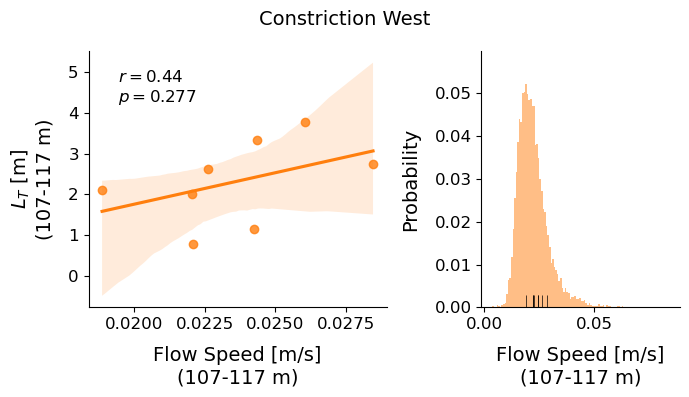

In [459]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 4), width_ratios=[1.5, 1])

sns.regplot(thorpe_data, x='speed', y='thorpe_scale', color='tab:orange', ax=ax[0])

txtstr = f'$r = {r:.2f}$\n$p = {p:.3e}$' if p < 0.001 else f'$r = {r:.2f}$\n$p = {p:.3f}$'
ax[0].annotate(txtstr, xy=(0.1, 0.8), xycoords='axes fraction', fontsize=12)

# horizontal flow speed distribution
sns.histplot(x=speed, stat='probability', color='tab:orange', edgecolor='none', alpha=0.5, ax=ax[1])

# speed during CTD profiles
sns.rugplot(thorpe_data, x='speed', height=0.05, color='black', linewidth=0.5, ax=ax[1])

ax[0].set_ylabel(r'$L_{T}$ [m]' + '\n(107-117 m)', fontsize=14, labelpad=10)
ax[1].set_ylabel('Probability', fontsize=14, labelpad=10)
fig.suptitle('Constriction West', fontsize=14)

for i in range(len(ax)):
    ax[i].set_xlabel('Flow Speed [m/s]\n(107-117 m)', fontsize=14, labelpad=10)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].tick_params(axis='both', labelsize=12)

plt.tight_layout(h_pad=1)
plt.savefig('../gallery/collab/gliders/flow_thorpe_w.svg', bbox_inches='tight')
plt.show()

In [434]:
# oxygen loggers
date = '2026-04-10'
loc = 'LZC'
sensor = 'minidot'
di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)

datasets = []
for _, row in di_sel.iterrows():
    oreader = ewg.o2_reader.O2Reader(row.lake, row.date, row.location, row.serial_id)
    ds = oreader.load()
    datasets.append(ds)
ds_do = mreader.create_instrument_chain(datasets)

# adcp
sensor = 'adcp'
di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
datasets = []
for _, row in di_sel.iterrows():
    areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
    ds = areader.load()
    ds = dsi.signal.valid_depths(ds, 0.5)
    ds['depth'] = ds['depth'].round(0)
    datasets.append(ds)

ds_adcp = mreader.create_adcp_chain(datasets, gap=np.arange(77, 87))

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:228: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:257: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_

In [441]:
err = 0.3    # minidot accuracy

# oxygen overturns
do_top = ds_do.do2_conc.sel(depth=115, method='nearest')
do_bot = ds_do.do2_conc.sel(depth=130, method='nearest')
do_diff = do_top - do_bot
print(do_top.depth.item(), do_bot.depth.item())

mask = do_diff < -err
t_sel = do_diff.time.where(mask, drop=True)

# horizontal flow speed
u = ds_adcp.vel.sel(dir='E').sel(depth=slice(115, 130))
v = ds_adcp.vel.sel(dir='N').sel(depth=slice(115, 130))
speed = np.sqrt(u**2 + v**2).mean(dim='depth')

speed_sel = np.unique(speed.reindex(time=t_sel, method='nearest'))

114.0 130.2


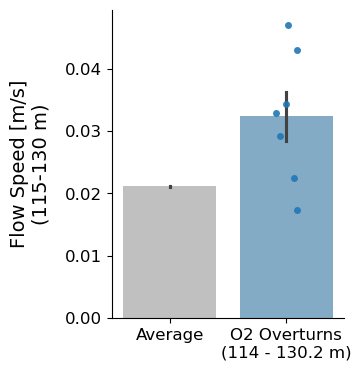

In [ ]:
fig, ax = plt.subplots(figsize=(3, 4))

sns.barplot(x=0, y=speed, color='silver', errorbar=('se', 1), ax=ax)

sns.stripplot(x=1, y=speed_sel, color='tab:blue', alpha=0.9, ax=ax)
sns.barplot(x=1, y=speed_sel, color='tab:blue', alpha=0.6, errorbar=('se', 1), ax=ax)

ax.set_ylabel('Flow Speed [m/s]\n(115-130 m)', fontsize=14, labelpad=10)
ax.set_xticks([0, 1], labels=['Average', 'O2 Overturns\n(114 - 130.2 m)'])
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../gallery/collab/gliders/flow_O2_c.svg', bbox_inches='tight')
plt.show()

In [419]:
# oxygen loggers
date = '2026-04-10'
loc = 'LZW'
sensor = 'minidot'
di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)

datasets = []
for _, row in di_sel.iterrows():
    oreader = ewg.o2_reader.O2Reader(row.lake, row.date, row.location, row.serial_id)
    ds = oreader.load()
    datasets.append(ds)
ds_do = mreader.create_instrument_chain(datasets)

# adcp
sensor = 'adcp'
row = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)].iloc[0]

areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds = areader.load()
ds = dsi.signal.valid_depths(ds, 0.5)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:228: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


In [428]:
err = 0.3    # minidot accuracy

# oxygen overturns
do_top = ds_do.do2_conc.sel(depth=115, method='nearest')
do_bot = ds_do.do2_conc.sel(depth=130, method='nearest')
do_diff = do_top - do_bot
print(do_top.depth.item(), do_bot.depth.item())

mask = do_diff < -err
t_sel = do_diff.time.where(mask, drop=True)

# horizontal flow speed
u = ds_adcp.vel.sel(dir='E').sel(depth=slice(115, 130))
v = ds_adcp.vel.sel(dir='N').sel(depth=slice(115, 130))
speed = np.sqrt(u**2 + v**2).mean(dim='depth')

speed_sel = np.unique(speed.reindex(time=t_sel, method='nearest'))

117.2 128.0


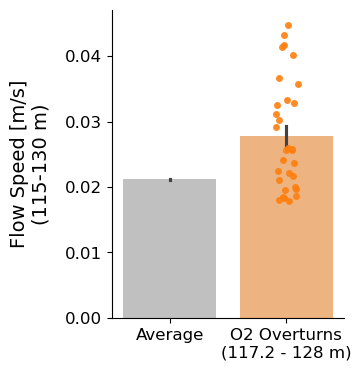

In [ ]:
fig, ax = plt.subplots(figsize=(3, 4))

sns.barplot(x=0, y=speed, color='silver', errorbar=('se', 1), ax=ax)

sns.stripplot(x=1, y=speed_sel, color='tab:orange', alpha=0.9, ax=ax)
sns.barplot(x=1, y=speed_sel, color='tab:orange', alpha=0.6, errorbar=('se', 1), ax=ax)

ax.set_ylabel('Flow Speed [m/s]\n(115-130 m)', fontsize=14, labelpad=10)
ax.set_xticks([0, 1], labels=['Average', 'O2 Overturns\n(117.2 - 128 m)'])
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../gallery/collab/gliders/flow_O2_w.svg', bbox_inches='tight')
plt.show()

### Internal Wave/Turbulence Regime

In [19]:
def bathy_transect(bathy, x0, y0, angle, ymin, ymax):
    angle_rad = np.deg2rad(angle)

    transect = [{'xsc': x0, 'ysc': y0, 'depth': bathy.sel(xsc=x0, ysc=y0, method='nearest').depth.item()}]

    # to N edge of constriction
    x, y = (x0, y0)
    while y < ymax:
        x = x + np.cos(angle_rad)
        y = y + np.sin(angle_rad)
        depth = bathy.sel(xsc=x, ysc=y, method='nearest').depth.item()
        transect.append({'xsc': x, 'ysc': y, 'depth': depth})

    # to S edge of constriction
    x, y = (x0, y0)
    while y > ymin:
        x = x - np.cos(angle_rad)
        y = y - np.sin(angle_rad)
        depth = bathy.sel(xsc=x, ysc=y, method='nearest').depth.item()
        transect.insert(0, {'xsc': x, 'ysc': y, 'depth': depth})        # maintain S to N order

    transect = pd.DataFrame(transect)
    transect['angle'] = angle
    transect['distance'] = np.arange(len(transect))    # 1 meter spacing
    
    return transect

In [510]:
# LZW location
xw, yw = (2679917, 1218754)
lat, lng = dsi.utils.ch1903_to_latlng(xw, yw)
f = dsi.efd.coriolis_frequency(lat)

In [511]:
ymin = 1218000
ymax = 1219000
angles = [90, 100]
palette = sns.color_palette('Oranges_r', n_colors=2)

In [512]:
transect_data = []
for angle in angles:
    df = bathy_transect(bathy, xw, yw, angle, ymin, ymax)
    transect_data.append(df)

transect_data = pd.concat(transect_data, ignore_index=True)

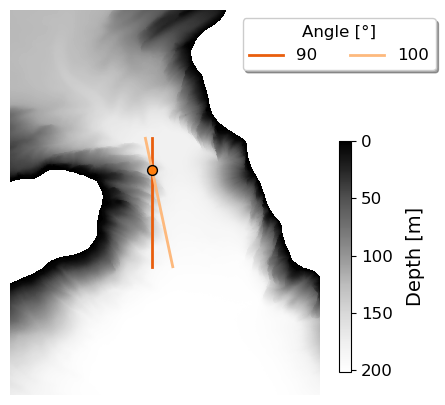

In [513]:
bathy_sel = bathy.sel(xsc=slice(2679000, 2681000), ysc=slice(1217000, 1220000))

fig, ax = plt.subplots(figsize=(5, 5))

im = ax.pcolormesh(bathy_sel['xsc'], bathy_sel['ysc'], bathy_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)
cbar = fig.colorbar(im, shrink=0.6, anchor=(0.0, 0.15), ax=ax)
cbar.set_label('Depth [m]', fontsize=14, labelpad=10)
cbar.ax.tick_params(labelsize=12)
cbar.ax.invert_yaxis()

sns.lineplot(transect_data, x='xsc', y='ysc', orient='y', hue='angle', palette=palette, lw=2, ax=ax)
ax.scatter(xw, yw, color='tab:orange', s=50, edgecolor='k', zorder=3)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)


ax.legend(title='Angle [°]', fontsize=12, title_fontsize=12, ncols=2, shadow=True, loc='upper right', bbox_to_anchor=(1.4, 1))

plt.savefig('../gallery/collab/gliders/transects_w.svg', bbox_inches='tight')
plt.show()

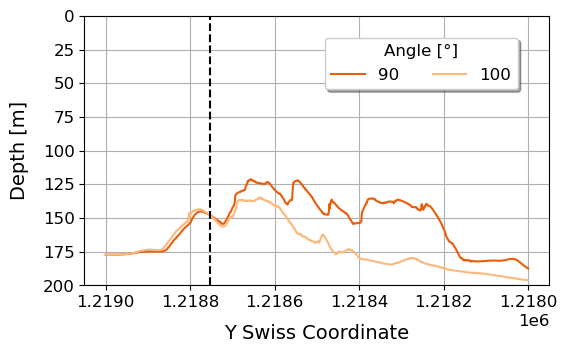

In [514]:
fig, ax = plt.subplots(figsize=(6, 3.5))

sns.lineplot(transect_data, x='ysc', y='depth', hue='angle', palette=palette, ax=ax)

ax.axvline(yw, color='black', linestyle='--')
ax.set_xlabel('Y Swiss Coordinate', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('')
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.set_ylim(0, 200)
ax.grid(True)
#ax.spines[['right', 'top']].set_visible(False)
ax.invert_xaxis()
ax.invert_yaxis()

ax.legend(title='Angle [°]', fontsize=12, title_fontsize=12, ncols=3, shadow=True, loc='upper right', bbox_to_anchor=(0.95, 0.95))

plt.savefig('../gallery/collab/gliders/bathy_transects.svg', bbox_inches='tight')
plt.show()    

In [515]:
wavenum_data = []
for ang, dat in transect_data.groupby("angle"):
    freqs, psd = scipy.signal.welch(dat.depth.values, fs=1, nperseg=len(dat), detrend='linear', scaling='density')
    freqs = freqs[1:]
    wavenum = 2 * np.pi * freqs
    psd = psd[1:]

    data = pd.DataFrame({
        'frequency': freqs,
        'wavenum': wavenum,
        'psd': psd
    })
    data['angle'] = ang
    wavenum_data.append(data)

wavenum_data = pd.concat(wavenum_data, ignore_index=True)

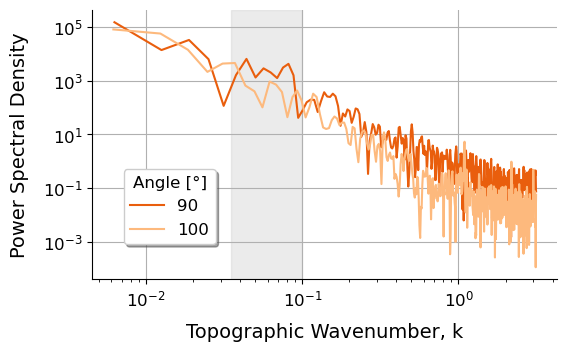

In [516]:
fig, ax = plt.subplots(figsize=(6, 3.5))

ax.axvspan(0.035, 0.1, color='silver', alpha=0.3)
sns.lineplot(wavenum_data, x='wavenum', y='psd', hue='angle', palette=palette, ax=ax)

ax.set_xlabel('Topographic Wavenumber, k', fontsize=14, labelpad=10)
ax.set_ylabel('Power Spectral Density', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.set_xscale('log')
ax.set_yscale('log')
ax.spines[['right', 'top']].set_visible(False)

ax.grid(True)
ax.legend(title='Angle [°]', fontsize=12, title_fontsize=12, ncols=1, shadow=True, loc='lower left', bbox_to_anchor=(0.05, 0.1))

plt.savefig('../gallery/collab/gliders/wavenum_k.svg', bbox_inches='tight')
plt.show()

In [517]:
# characteristic topographic wavenumber
k = (0.035 + 0.1) / 2
k

0.0675

In [518]:
date = '2026-04-10'
loc = 'LZW'
sensor = 'adcp'
row = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)].iloc[0]

areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds_adcp = areader.load()
ds_adcp = dsi.signal.valid_depths(ds_adcp, 0.5).sel(depth=slice(None, 135))

# depth range from ADCP (bottom 10 meters)
z_min = ds_adcp.depth.max().item() - 10
z_max = ds_adcp.depth.max().item()

t_start = ds_adcp.time.values[0]
t_end = ds_adcp.time.values[-1]

In [519]:
pl_w = ["P6W", "VMPW"]
di_sel = di_ctd[di_ctd['profile_loc'].isin(pl_w) & (di_ctd['date'].between(t_start, t_end))]

# buoyancy frequency
N2_data = []
for i, p in tqdm(di_sel.iterrows(), total=len(di_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()

    if ds['depth'].max().item() > (z_max + z_min) / 2:
        # buoyancy frequency
        rho_ba = dsi.signal.binned_average_z(ds['rho'], 1)    # 1 meter binned average
        rho_ba_sort = dsi.signal.order_profile(rho_ba, surfmax=False, reassign_depth=True)
        N2 = dsi.efd.brunt_vaisala_frequency(rho_ba_sort)
        
        # select depth range from ADCP
        N2 = N2.sel(depth=slice(z_min, z_max)).to_dataframe().reset_index()
        N2[['date', 'time', 'idx']] = p.date, p.time, i
        N2_data.append(N2)

N2_data = pd.concat(N2_data, ignore_index=True)

  0%|          | 0/11 [00:00<?, ?it/s]

In [520]:
# average over depth for each profile
N2_pavg = N2_data.groupby(['date', 'time'])['N2'].mean().reset_index()

# average across profiles for each date
N2_davg = N2_pavg.groupby('date')['N2'].mean().reset_index()

N = np.sqrt(N2_davg['N2'].mean())
N

np.float64(0.0008776700103619543)

In [521]:
# intrinsic frequency and inverse Froude number
res = []
for ang, dat in transect_data.groupby("angle"):
    h = dat.depth.max() - dat.depth.min()
    
    # project velocity along angle
    vel = dsi.signal.velocity_projection(ds_adcp.vel, ang).sel(depth=slice(z_min, z_max))

    # mask for velocity in same direction all depths
    mask = vel.min(dim='depth') * vel.max(dim='depth') > 0

    # average over depth
    U = vel.where(mask, drop=True).mean(dim='depth')

    freq_intr = U * k
    F_inv = N * h / U

    data = pd.DataFrame({
        'angle': ang,
        'time': U.time,
        'vel': U,
        'freq_intr': freq_intr,
        'F_inv': F_inv
    })
    res.append(data)

res_df = pd.concat(res, ignore_index=True).sort_values(['angle', 'time'])
res_df[['abs_vel', 'abs_freq_intr', 'abs_F_inv']] = abs(res_df[['vel', 'freq_intr', 'F_inv']])

In [522]:
# convert to xarray
res = []
for ang, dat in res_df.groupby('angle'):
    ds = xr.Dataset(dat.drop(columns='angle').set_index('time'))
    ds = ds.expand_dims(angle=[ang])
    res.append(ds)

res_ds = xr.concat(res, dim='angle', join='outer')

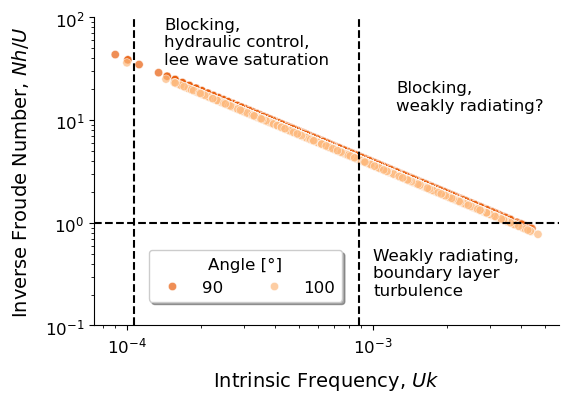

In [523]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.axhline(1, color='black', linestyle='--')
ax.axvline(N, color='black', linestyle='--')
ax.axvline(f, color='black', linestyle='--')
sns.scatterplot(res_df, x='abs_freq_intr', y='abs_F_inv', hue='angle', palette=palette, alpha=0.7, ax=ax)

ax.annotate('Blocking,\nhydraulic control,\nlee wave saturation', 
            xy=(0.15, 0.85), xycoords='axes fraction', fontsize=12)
ax.annotate('Blocking,\nweakly radiating?', 
            xy=(0.65, 0.7), xycoords='axes fraction', fontsize=12)
ax.annotate('Weakly radiating,\nboundary layer\nturbulence', 
            xy=(0.6, 0.1), xycoords='axes fraction', fontsize=12)

ax.set_xlabel('Intrinsic Frequency, ' + r'$Uk$', fontsize=14, labelpad=10)
ax.set_ylabel('Inverse Froude Number, ' + r'$Nh/U$', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-1, 1e2)

ax.legend(title='Angle [°]', fontsize=12, title_fontsize=12, ncols=2, shadow=True, loc='lower left', bbox_to_anchor=(0.1, 0.05))

plt.savefig('../gallery/collab/gliders/regime.svg', bbox_inches='tight')
plt.show()

In [525]:
thorpe_data = []
for _, p in tqdm(di_sel.iterrows(), total=len(di_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()

    # thorpe displacement
    rho = ds['rho']
    depth = ds['depth']
    rho_ra = dsi.signal.rolling_average_z(rho, ra_window=1)
    rho_ra_sort = dsi.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
    thorpe_displacement = depth - rho_ra_sort.depth.values
    thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

    data = pd.DataFrame({
        'date': p.date,
        'time_local': p.time,
        'time_utc': ds.time.values,
        'depth': depth.values,
        'thorpe': thorpe_displacement.values
    })
    thorpe_data.append(data)

thorpe_data = pd.concat(thorpe_data, ignore_index=True)

  0%|          | 0/11 [00:00<?, ?it/s]

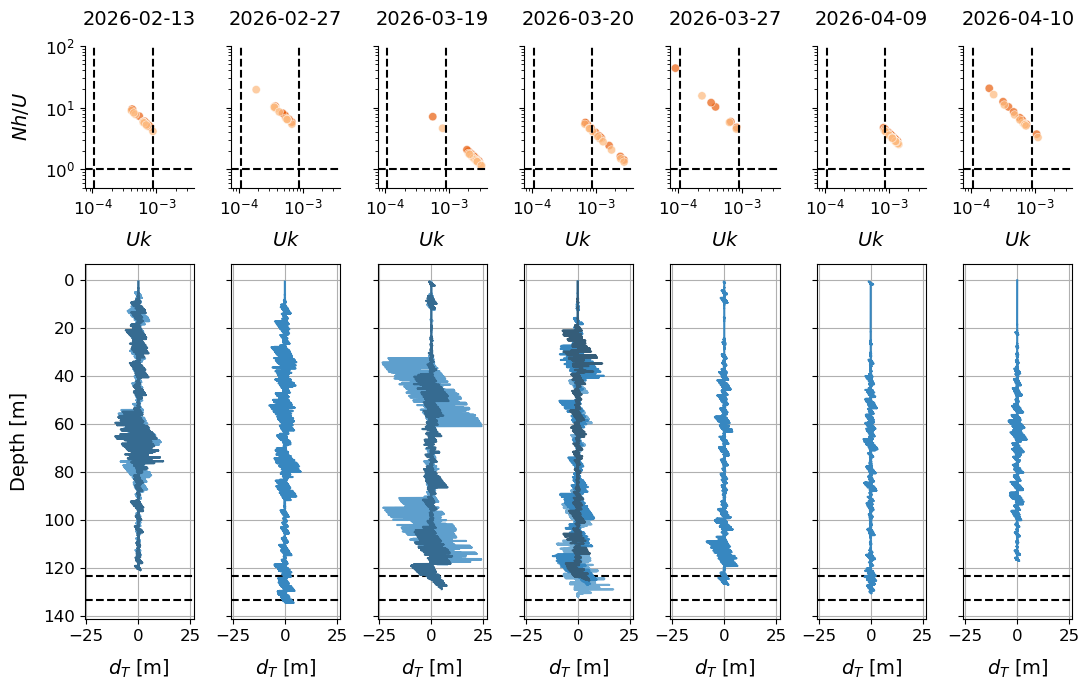

In [540]:
fig, ax = plt.subplots(nrows=2, ncols=thorpe_data.date.nunique(), figsize=(11, 7), sharex='row', sharey='row', height_ratios=[1, 2.5])

for i, (dt, dat) in enumerate(thorpe_data.groupby('date')):
    # select data from 3 hours prior to CTD profiles
    t0 = dat.time_utc.min() - pd.Timedelta(hours=3)
    tf = dat.time_utc.max()
    df = res_df[res_df['time'].between(t0, tf)]

    # intrinsic frequency and inverse froude number
    ax[0, i].axhline(1, color='black', linestyle='--')
    ax[0, i].axvline(N, color='black', linestyle='--')
    ax[0, i].axvline(f, color='black', linestyle='--')
    sns.scatterplot(df, x='abs_freq_intr', y='abs_F_inv', hue='angle', palette=palette, alpha=0.7, ax=ax[0, i], legend=False)

    ax[0, i].set_xlabel(r'$Uk$', fontsize=14, labelpad=10)
    ax[0, i].set_ylabel(r'$Nh/U$', fontsize=14, labelpad=10)
    ax[0, i].set_title(dt.date(), fontsize=14, pad=15)
    ax[0, i].tick_params(axis='both', labelsize=12)

    ax[0, i].spines[['right', 'top']].set_visible(False)
    ax[0, i].set_xscale('log')
    ax[0, i].set_yscale('log')
    ax[0, i].set_ylim(0.5e-0, 1e2)

    # thorpe displacement
    ax[1, i].axhline(z_min, color='black', linestyle='--')
    ax[1, i].axhline(z_max, color='black', linestyle='--')
    sns.lineplot(dat, x='thorpe', y='depth', orient='y', hue='time_local', ax=ax[1, i], palette='Blues_d', legend=False)

    ax[1, i].set_xlabel(r'$d_{T}$ [m]', fontsize=14, labelpad=10)
    ax[1, i].tick_params(axis='both', labelsize=12)
    ax[1, i].grid(True)

ax[1, 0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

ax[1, 0].invert_yaxis()

plt.tight_layout(h_pad=1, w_pad=1)
plt.savefig('../gallery/collab/gliders/regime_thorpe.svg', bbox_inches='tight')
plt.show()

### Glider Transects

In [20]:
xc = 2680050
yc = 1218800
ymin = 1218800
ymax = 1220000
t_n = bathy_transect(bathy, xc, yc, 125, ymin, ymax)

ymin = 1216500
ymax = 1218800
t_s = bathy_transect(bathy, xc, yc, 100, ymin, ymax)

t_ns = pd.concat([t_n, t_s], ignore_index=True)

In [21]:
xw = 2679850
yw = 1218500
ymin = 1217800
ymax = 1219300
t_w1 = bathy_transect(bathy, xw, yw, 100, ymin, ymax)
t_w1['idx'] = 1

xw = 2679900
yw = 1218500
ymin = 1217800
ymax = 1219300
t_w2 = bathy_transect(bathy, xw, yw, 100, ymin, ymax)
t_w2['idx'] = 2

xw = 2679950
yw = 1218500
ymin = 1217800
ymax = 1219300
t_w3 = bathy_transect(bathy, xw, yw, 100, ymin, ymax)
t_w3['idx'] = 3

t_w = pd.concat([t_w1, t_w2, t_w3], ignore_index=True)
palette_w = sns.color_palette('Oranges_r', n_colors=6)[::2]

In [22]:
xc = 2680100
yc = 1218800
ymin = 1218700
ymax = 1218870
t_ew1 = bathy_transect(bathy, xc, yc, 15, ymin, ymax)
t_ew1['idx'] = 1

xc = 2680100
yc = 1218600
ymin = 1218510
ymax = 1218690
t_ew2 = bathy_transect(bathy, xc, yc, 15, ymin, ymax)
t_ew2['idx'] = 2

xc = 2680100
yc = 1218400
ymin = 1218320
ymax = 1218510
t_ew3 = bathy_transect(bathy, xc, yc, 15, ymin, ymax)
t_ew3['idx'] = 3

t_ew = pd.concat([t_ew1, t_ew2, t_ew3], ignore_index=True)
palette_ew = sns.color_palette('Blues_r', n_colors=6)[::2]

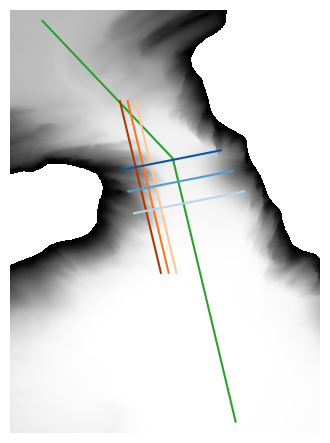

In [23]:
bathy_sel = bathy.sel(xsc=slice(2679000, 2681000), ysc=slice(1216400, 1220100))

fig, ax = plt.subplots(figsize=(4, 5.5))

im = ax.pcolormesh(bathy_sel['xsc'], bathy_sel['ysc'], bathy_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

sns.lineplot(t_ns, x='xsc', y='ysc', color='tab:green', ax=ax)
sns.lineplot(t_w, x='xsc', y='ysc', hue='idx', palette=palette_w, ax=ax, legend=False)
sns.lineplot(t_ew, x='xsc', y='ysc', hue='idx', palette=palette_ew, ax=ax, legend=False)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/collab/gliders/glider_map.svg', bbox_inches='tight')
plt.show()

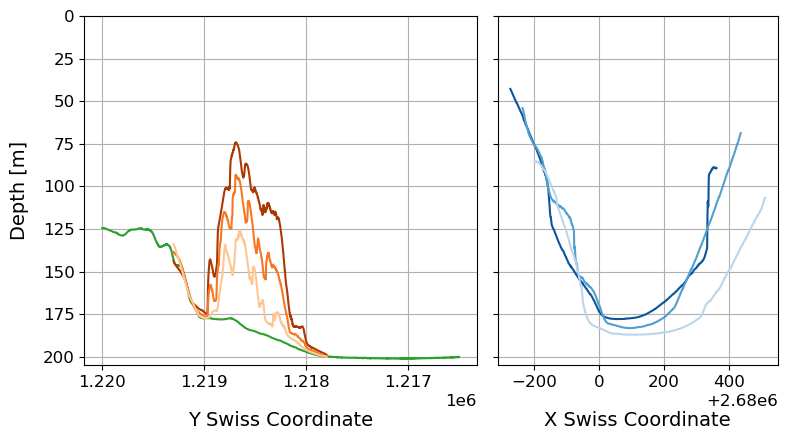

In [24]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4.5), sharey=True, width_ratios=[1.4, 1])

sns.lineplot(t_ns, x='ysc', y='depth', color='tab:green', ax=ax[0])
sns.lineplot(t_w, x='ysc', y='depth', hue='idx', palette=palette_w, ax=ax[0], legend=False)
sns.lineplot(t_ew, x='xsc', y='depth', hue='idx', palette=palette_ew, ax=ax[1], legend=False)

ax[0].set_xlabel('Y Swiss Coordinate', fontsize=14, labelpad=15)
ax[1].set_xlabel('X Swiss Coordinate', fontsize=14, labelpad=15)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].xaxis.get_offset_text().set_fontsize(12)
    ax[i].grid(True)

ax[0].invert_xaxis()
ax[0].set_ylim(0, 205)
ax[0].invert_yaxis()

plt.tight_layout()
plt.savefig('../gallery/collab/gliders/glider_bathy.svg', bbox_inches='tight')
plt.show()    